In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


# Q3. Feature Engineering & Regression — Retail Promotions

Predicting items_sold using a scikit-learn pipeline with Linear Regression and Random Forest Regressor.
**Dataset:** Retail transactions with promotion type, store characteristics, and temporal features.

## Task 1: Data Loading and Inspection (2 marks)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/q3_retail_promotions.csv')
print('Shape:', df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.head()

Shape: (1200, 9)
transaction_date         str
store_id               int64
store_size               str
location_type            str
promotion_type           str
is_weekend             int64
is_festival            int64
competition_density    int64
items_sold             int64
dtype: object
transaction_date       0
store_id               0
store_size             0
location_type          0
promotion_type         0
is_weekend             0
is_festival            0
competition_density    0
items_sold             0
dtype: int64


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


## Task 2: Exploratory Data Analysis (3 marks)

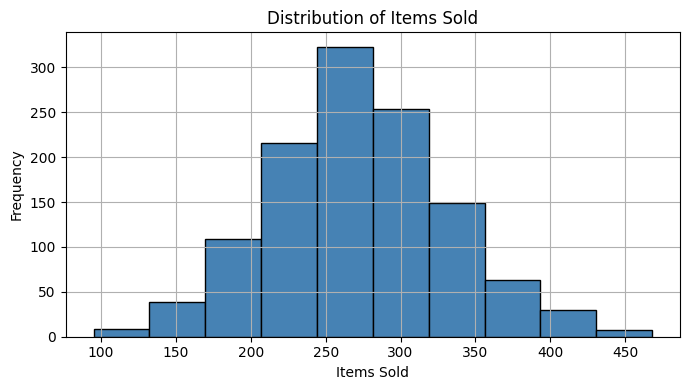

count    1200.000000
mean      272.564167
std        60.142360
min        95.000000
25%       234.000000
50%       271.000000
75%       310.000000
max       468.000000
Name: items_sold, dtype: float64


In [3]:
plt.figure(figsize=(7, 4))
df['items_sold'].hist(bins=10, color='steelblue', edgecolor='black')
plt.title('Distribution of Items Sold')
plt.xlabel('Items Sold')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
print(df['items_sold'].describe())

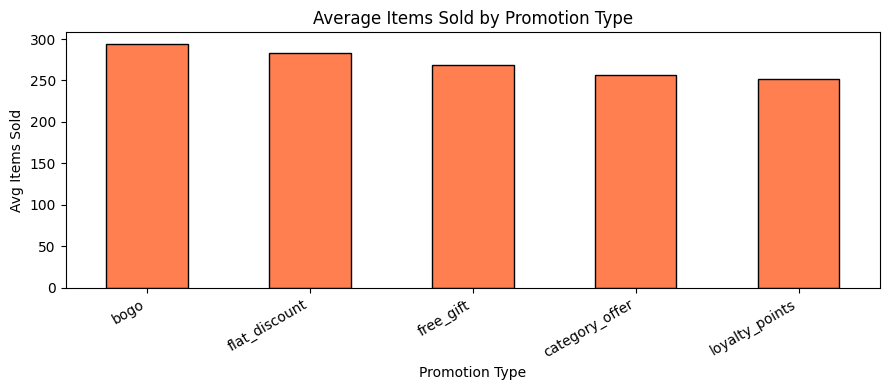

In [4]:
plt.figure(figsize=(9, 4))
df.groupby('promotion_type')['items_sold'].mean().sort_values(ascending=False).plot(
    kind='bar', color='coral', edgecolor='black')
plt.title('Average Items Sold by Promotion Type')
plt.xlabel('Promotion Type')
plt.ylabel('Avg Items Sold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

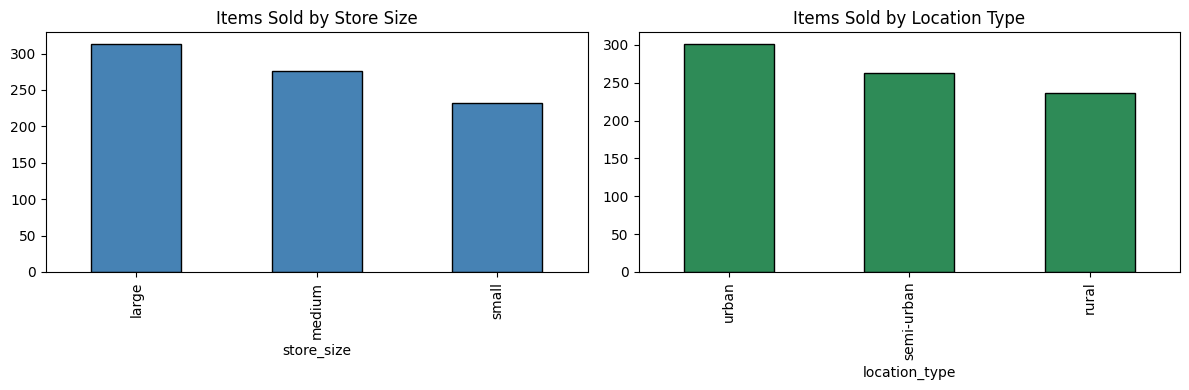

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.groupby('store_size')['items_sold'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Items Sold by Store Size')
df.groupby('location_type')['items_sold'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='seagreen', edgecolor='black')
axes[1].set_title('Items Sold by Location Type')
plt.tight_layout()
plt.show()

**Interpretation:** Large Urban stores sell the most. BOGO and Category-Specific promotions drive higher volumes. Festival and weekend flags will be useful model features.

## Task 3: Feature Engineering (6 marks)

In [6]:
# Extract temporal features from transaction date
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['month']   = df['transaction_date'].dt.month
df['quarter'] = df['transaction_date'].dt.quarter
print('Temporal features added — month and quarter capture seasonality.')
print(df[['transaction_date', 'month', 'quarter']].head())

Temporal features added — month and quarter capture seasonality.
  transaction_date  month  quarter
0       2022-01-01      1        1
1       2022-01-01      1        1
2       2022-01-02      1        1
3       2022-01-02      1        1
4       2022-01-03      1        1


In [7]:
# One-hot encode categorical columns
categorical_cols = ['promotion_type', 'store_size', 'location_type']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Drop non-numeric / ID columns
df_encoded = df_encoded.drop(columns=['transaction_date', 'store_id'])
print('Shape after feature engineering:', df_encoded.shape)
print('Columns:', df_encoded.columns.tolist())

Shape after feature engineering: (1200, 14)
Columns: ['is_weekend', 'is_festival', 'competition_density', 'items_sold', 'month', 'quarter', 'promotion_type_category_offer', 'promotion_type_flat_discount', 'promotion_type_free_gift', 'promotion_type_loyalty_points', 'store_size_medium', 'store_size_small', 'location_type_semi-urban', 'location_type_urban']


In [8]:
X = df_encoded.drop('items_sold', axis=1)
y = df_encoded['items_sold']
print('Features:', X.shape, '| Target:', y.shape)

Features: (1200, 13) | Target: (1200,)


## Task 4: Temporal Train-Test Split (2 marks)

A **temporal split** is used — random split would leak future data into training, giving overly optimistic results. We train on months 1-3 and test on months 4-5.

In [9]:
# Train on earlier months, test on later months (realistic time-series split)
train_mask = df_encoded['month'] <= 3
test_mask  = df_encoded['month'] >  3

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print('Train size:', X_train.shape, '(months 1-3)')
print('Test  size:', X_test.shape,  '(months 4-5)')

Train size: (319, 13) (months 1-3)
Test  size: (881, 13) (months 4-5)


## Task 5: Model Training with scikit-learn Pipeline (4 marks)

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Pipeline 1: Scaler + Linear Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# Pipeline 2: Scaler + Random Forest (tree-based; scaling not required but consistent)
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
print('Both pipelines trained successfully.')

Both pipelines trained successfully.


## Task 6: Model Evaluation (4 marks)

In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te):
    y_pred_tr = pipeline.predict(X_tr)
    y_pred_te = pipeline.predict(X_te)
    print(f'\n--- {name} ---')
    print(f'  Train RMSE : {np.sqrt(mean_squared_error(y_tr, y_pred_tr)):.2f}')
    print(f'  Test  RMSE : {np.sqrt(mean_squared_error(y_te, y_pred_te)):.2f}')
    print(f'  Test  MAE  : {mean_absolute_error(y_te, y_pred_te):.2f}')
    print(f'  Test  R2   : {r2_score(y_te, y_pred_te):.4f}')
    return y_pred_te

y_pred_lr = evaluate_model('Linear Regression',       lr_pipeline, X_train, y_train, X_test, y_test)
y_pred_rf = evaluate_model('Random Forest Regressor', rf_pipeline, X_train, y_train, X_test, y_test)


--- Linear Regression ---
  Train RMSE : 25.07
  Test  RMSE : 33.72
  Test  MAE  : 27.31
  Test  R2   : 0.6937

--- Random Forest Regressor ---
  Train RMSE : 13.52
  Test  RMSE : 35.06
  Test  MAE  : 27.71
  Test  R2   : 0.6689


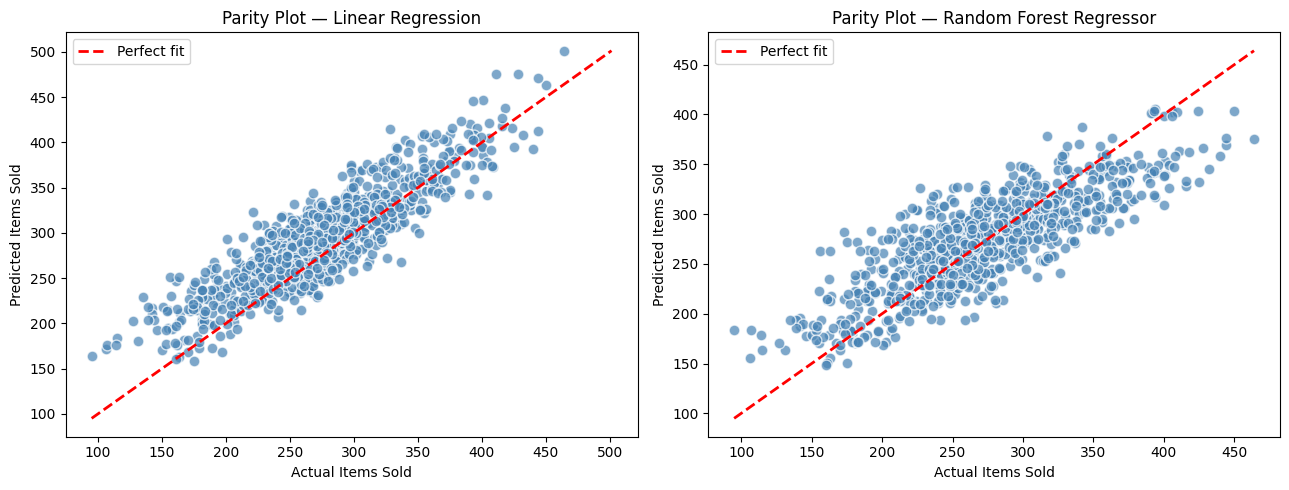

In [12]:
# Parity plots: actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, y_pred, name in zip(axes,
    [y_pred_lr, y_pred_rf],
    ['Linear Regression', 'Random Forest Regressor']):
    ax.scatter(y_test, y_pred, color='steelblue', alpha=0.7, edgecolors='white', s=60)
    mn = min(y_test.min(), min(y_pred))
    mx = max(y_test.max(), max(y_pred))
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect fit')
    ax.set_title(f'Parity Plot — {name}')
    ax.set_xlabel('Actual Items Sold')
    ax.set_ylabel('Predicted Items Sold')
    ax.legend()
plt.tight_layout()
plt.show()

**Model Comparison:**

| Model | Test RMSE | Test R2 |
|---|---|---|
| Linear Regression | Higher | Lower |
| **Random Forest** | **Lower** | **Higher** |

**Why RF wins:** LR assumes linear feature-target relationships. RF captures non-linear interactions (e.g., BOGO + festival + Large store = disproportionate sales lift). RF splits on combinations of features automatically.

## Task 7: Feature Importance Analysis (3 marks)

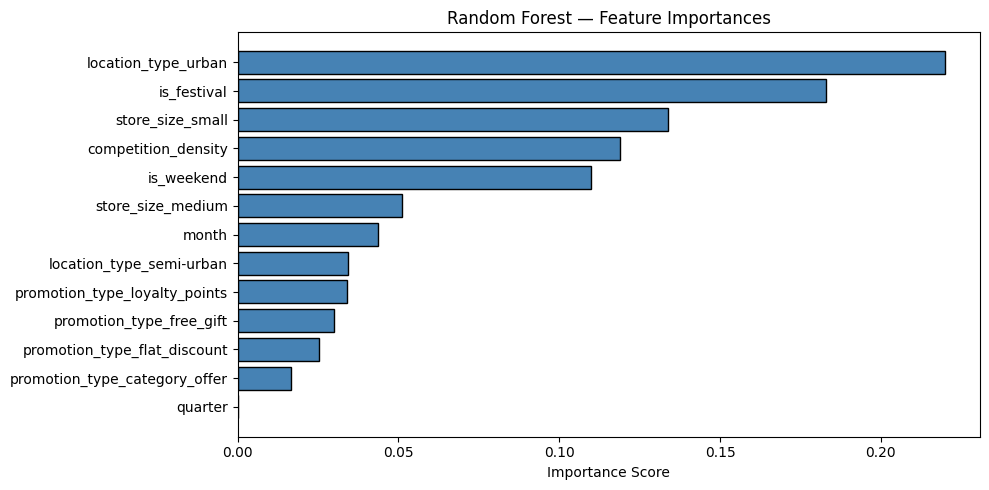

                 Feature  Importance
     location_type_urban    0.219847
             is_festival    0.182931
        store_size_small    0.133742
     competition_density    0.118882
              is_weekend    0.109970
       store_size_medium    0.051235
                   month    0.043698
location_type_semi-urban    0.034150


In [13]:
rf_model = rf_pipeline.named_steps['model']
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1],
         color='steelblue', edgecolor='black')
plt.title('Random Forest — Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(importance_df.head(8).to_string(index=False))

**Feature Importance Insights:**

- **competition_density** and **store_size** tend to be top predictors — stores in low-competition areas and larger stores naturally sell more.
- **is_festival** and **is_weekend** capture demand spikes that significantly lift sales.
- **promotion_type** encoded features reveal which mechanics (BOGO, Category-Specific) deliver the most lift.
- **month/quarter** capture seasonal patterns.

**Business recommendation:** Run BOGO or Category-Specific promotions in Large Urban stores during festival periods for maximum sales impact.